In [1]:
%load_ext autoreload
%autoreload 2

import torch
import numpy as np
import tqdm
import matplotlib.pyplot as plt

import cmasher as cmr
import numpy as np
import pickle
from scipy.stats import pearsonr

from utils.misc.results_saving import save_results, load_results, load_results_for_model_and_revisions, load_all_results
from utils.model_definitions.text_automodel_wrapper import TextModelSpecifications

plt.rcParams.update({'font.size': 14})

In [2]:
all_results = load_all_results(should_normalize_scores_across_models=False, base_path='results')

# Single Model, Average Metric vs Average Main Score for each layer

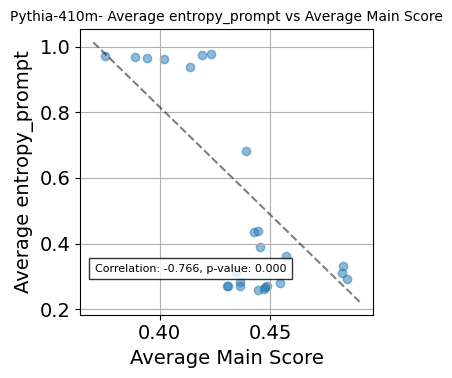

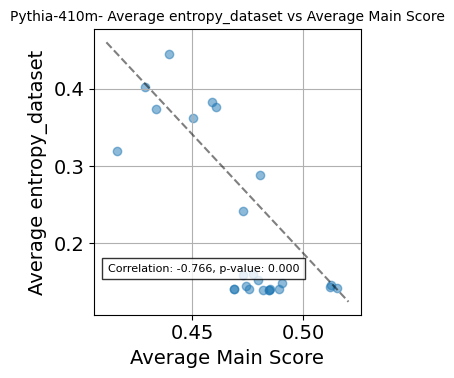

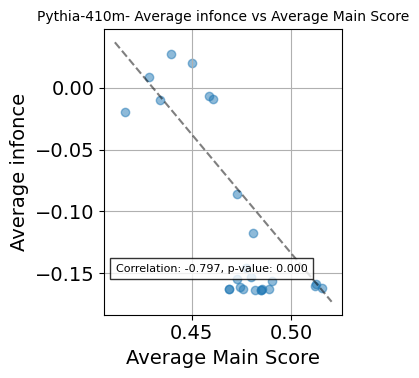

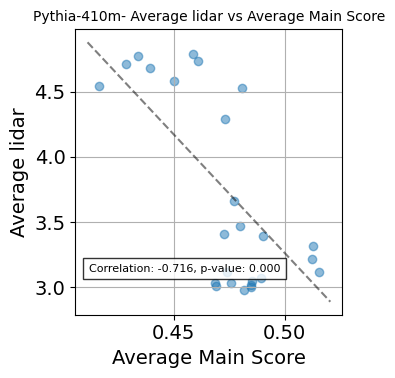

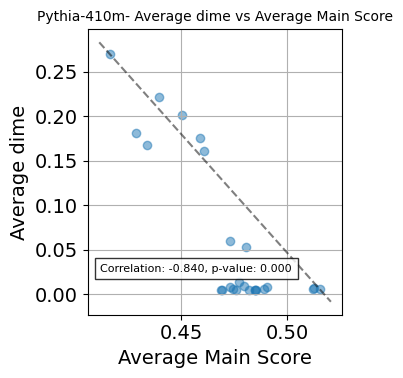

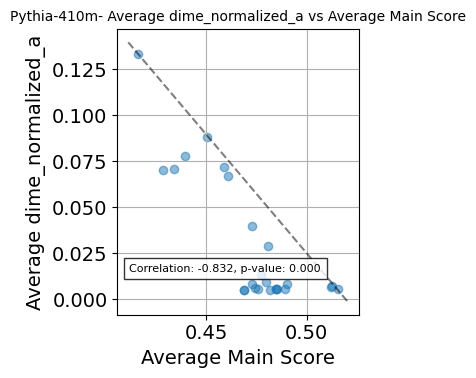

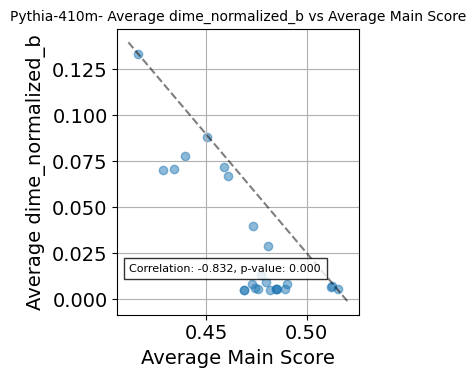

In [28]:
METRICS_CHOICES = ['entropy_prompt', 
           'entropy_dataset',
           'infonce',
           'lidar',
           'dime',
           'dime_normalized_a',
           'dime_normalized_b']

model_specs = TextModelSpecifications(
    model_family='Pythia',
    model_size='410m',
    revision='main'
)

for METRIC_TO_PLOT in METRICS_CHOICES:
    x_values = []  # Main scores
    y_values = []  # Entropy values
    for layer in all_results[model_specs.model_family][model_specs.model_size]['main'].keys():
        if not layer.startswith('layer_'):
            continue
            
        layer_results = all_results[model_specs.model_family][model_specs.model_size]['main'][layer]
        
        # Calculate average main score for this layer
        main_scores = []
        metric_values = []
        for task_name, task_results in layer_results.items():
            try:
                main_scores.append(task_results['main_score'])
                
                if METRIC_TO_PLOT == 'entropy_prompt':
                    metric_values.append(task_results['entropy_prompt']['maxEntropy'])
                elif METRIC_TO_PLOT == 'entropy_dataset':
                    metric_values.append(task_results['entropy_dataset']['maxEntropy'])
                elif METRIC_TO_PLOT == 'infonce':
                    metric_values.append(task_results['infonce']['raw'])
                elif METRIC_TO_PLOT == 'lidar':
                    metric_values.append(task_results['lidar']['raw'])
                elif METRIC_TO_PLOT == 'dime':
                    metric_values.append(task_results['dime']['raw'])
                elif METRIC_TO_PLOT == 'dime_normalized_a':
                    metric_values.append(task_results['dime']['logD'] / task_results['entropy_dataset']['logD'])
                elif METRIC_TO_PLOT == 'dime_normalized_b':
                    metric_values.append(task_results['dime']['raw'] / task_results['entropy_dataset']['raw'])

            except KeyError as e:
                #print(f"KeyError for task {task_name} in layer {layer}", e)
                main_scores.remove(main_scores[-1])
                continue
                
        if main_scores:
            x_values.append(np.mean(main_scores))
            y_values.append(np.mean(metric_values))

    # Create square scatter plot
    plt.figure(figsize=(4, 4))
    plt.scatter(x_values, y_values, alpha=0.5)
    plt.xlabel('Average Main Score')
    plt.ylabel(f'Average {METRIC_TO_PLOT}')
    plt.title(f'{model_specs.model_family}-{model_specs.model_size}- Average {METRIC_TO_PLOT} vs Average Main Score', fontsize=10)
    plt.grid(True)

    # Calculate and display correlation coefficient
    correlation, p_value = pearsonr(x_values, y_values)
    plt.text(0.05, 0.15, f'Correlation: {correlation:.3f}, p-value: {p_value:.3f}', 
             transform=plt.gca().transAxes, 
             bbox=dict(facecolor='white', alpha=0.8), fontsize=8)

    # Add negative diagonal line
    x_min, x_max = plt.xlim()
    y_min, y_max = plt.ylim()
    plt.plot([x_min, x_max], [y_max, y_min], 'k--', alpha=0.5)

    plt.tight_layout()
    plt.show()

# Single Layer, Metric vs Main Score for each task

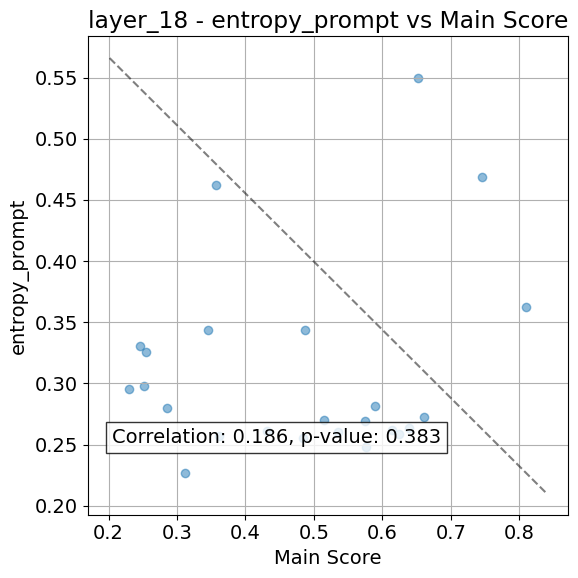

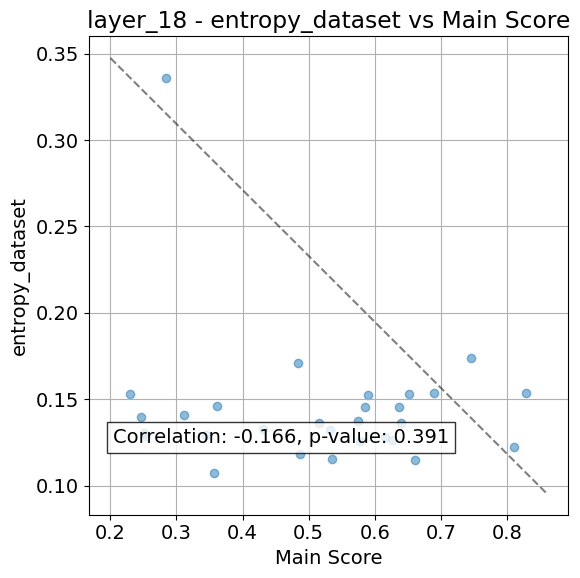

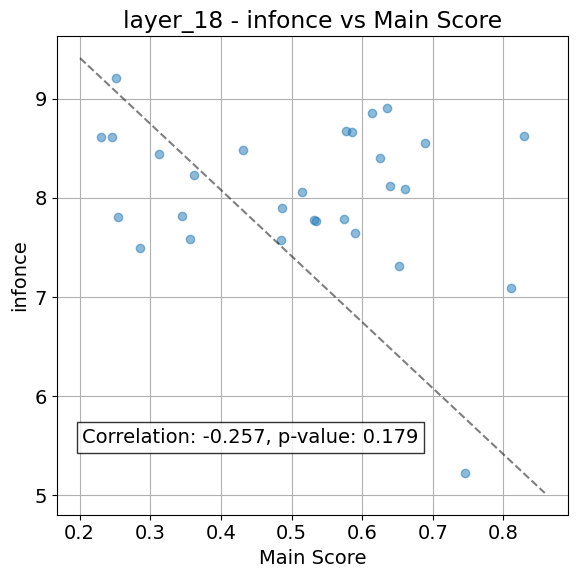

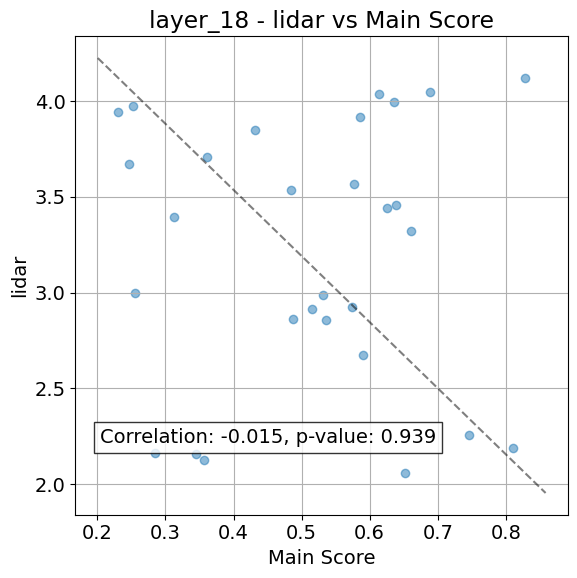

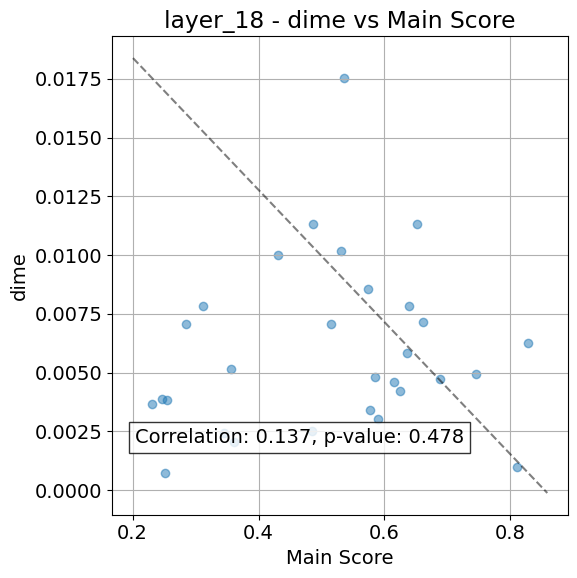

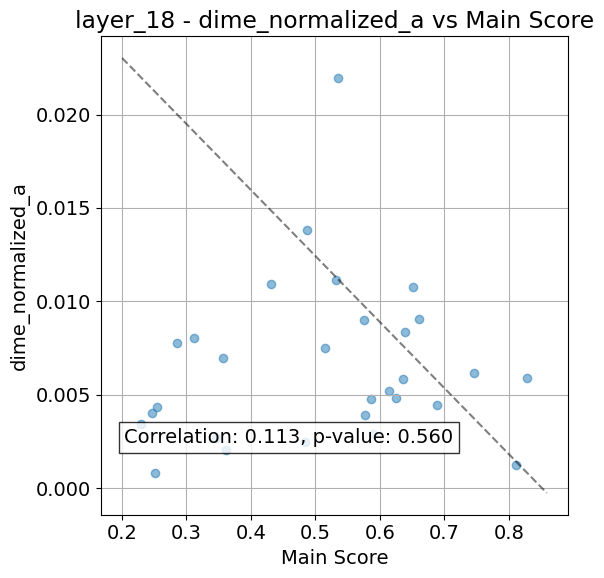

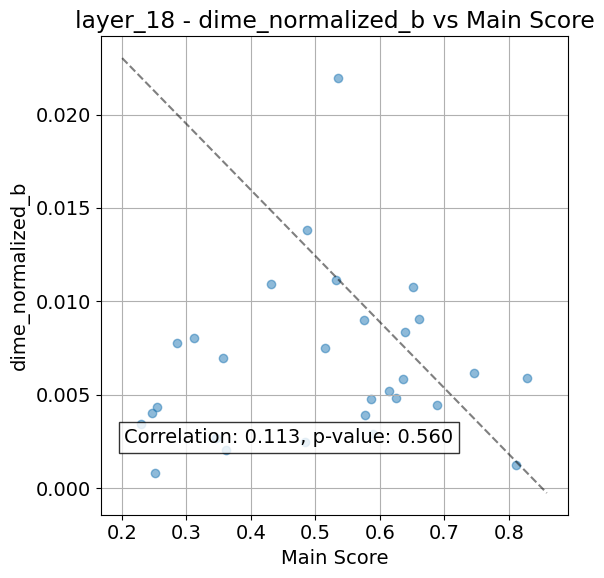

In [8]:
METRICS_CHOICES = ['entropy_prompt', 
           'entropy_dataset',
           'infonce',
           'lidar',
           'dime',
           'dime_normalized_a',
           'dime_normalized_b']
LAYER_TO_PLOT = 'layer_18'

model_specs = TextModelSpecifications(
    model_family='Pythia',
    model_size='410m',
    revision='main'
)

for METRIC_TO_PLOT in METRICS_CHOICES:
    main_scores = []
    metric_values = []

    for layer in all_results[model_specs.model_family][model_specs.model_size]['main'].keys():
        if not layer.startswith('layer_'):
            continue
        if layer != LAYER_TO_PLOT:
            continue
            
        layer_results = all_results[model_specs.model_family][model_specs.model_size]['main'][layer]
        for task_name, task_results in layer_results.items():
            try:
                main_scores.append(task_results['main_score'])
                
                if METRIC_TO_PLOT == 'entropy_prompt':
                    metric_values.append(task_results['entropy_prompt']['maxEntropy'])
                elif METRIC_TO_PLOT == 'entropy_dataset':
                    metric_values.append(task_results['entropy_dataset']['maxEntropy'])
                elif METRIC_TO_PLOT == 'infonce':
                    metric_values.append(task_results['infonce']['raw'])
                elif METRIC_TO_PLOT == 'lidar':
                    metric_values.append(task_results['lidar']['raw'])
                elif METRIC_TO_PLOT == 'dime':
                    metric_values.append(task_results['dime']['raw'])
                elif METRIC_TO_PLOT == 'dime_normalized_a':
                    metric_values.append(task_results['dime']['logD'] / task_results['entropy_dataset']['logD'])
                elif METRIC_TO_PLOT == 'dime_normalized_b':
                    metric_values.append(task_results['dime']['raw'] / task_results['entropy_dataset']['raw'])

            except KeyError as e:
                #print(f"KeyError for task {task_name} in layer {layer}", e)
                main_scores.remove(main_scores[-1])
                continue

    # Create square scatter plot
    plt.figure(figsize=(6, 6))
    plt.scatter(main_scores, metric_values, alpha=0.5)
    plt.xlabel('Main Score')
    plt.ylabel(f'{METRIC_TO_PLOT}')
    plt.title(f'{LAYER_TO_PLOT} - {METRIC_TO_PLOT} vs Main Score')
    plt.grid(True)

    # Calculate and display correlation coefficient
    correlation, p_value = pearsonr(main_scores, metric_values)
    plt.text(0.05, 0.15, f'Correlation: {correlation:.3f}, p-value: {p_value:.3f}', 
             transform=plt.gca().transAxes, 
             bbox=dict(facecolor='white', alpha=0.8))

    # Add negative diagonal line
    x_min, x_max = plt.xlim()
    y_min, y_max = plt.ylim()
    plt.plot([x_min, x_max], [y_max, y_min], 'k--', alpha=0.5)

    plt.tight_layout()
    plt.show()

# Main Score Across Layers

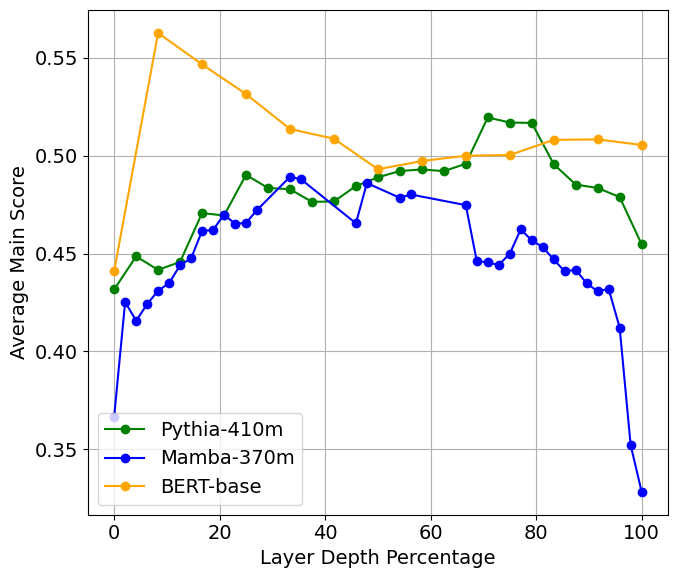

In [6]:
# plot roberta base main score across layers

specs_list = [
    TextModelSpecifications(
        model_family='Pythia',
        model_size='410m',
        revision='main',
        ignore_checks=True
    ),
    TextModelSpecifications(
        model_family='mamba',
        model_size='370m',
        revision='main',
        ignore_checks=True
    ),
    TextModelSpecifications(
        model_family='bert',
        model_size='base',
        revision='main',
        ignore_checks=True
    ),

]

model_to_label = {
    'mamba': 'Mamba-370m',
    'bert': 'BERT-base',
    'Pythia': 'Pythia-410m'
}

plt.figure(figsize=(7, 6))

for specs in specs_list:    
    average_main_scores = []
    std_main_scores = []
    layer_nums = []
    
    for layer in all_results[specs.model_family][specs.model_size]['main'].keys():
        if not layer.startswith('layer_') or '_last' in layer:
            continue
            
        layer_num = int(layer.split('_')[1])
        layer_nums.append(layer_num)
        
        layer_results = all_results[specs.model_family][specs.model_size]['main'][layer]
        main_scores = []

        for task_name, task_results in layer_results.items():
            if 'main_score' not in task_results:
                continue
            main_scores.append(task_results['main_score'])

        average_main_scores.append(np.mean(main_scores))
        std_main_scores.append(np.std(main_scores))

    # Sort by layer number
    sorted_indices = np.argsort(layer_nums)
    layer_nums = np.array(layer_nums)[sorted_indices]
    depth_percentages = np.linspace(0, 100, len(layer_nums))
    average_main_scores = np.array(average_main_scores)[sorted_indices]

    # replace values higher than 0.6 with nan
    average_main_scores = [(np.nan, idx) if score > 0.6 else (score, idx) for idx,score in enumerate(average_main_scores)]
    remaining_layers = [idx for idx, score in enumerate(average_main_scores) if score[0] is not np.nan]
    average_main_scores = [score[0] for score in average_main_scores if score[0] is not np.nan]
    std_main_scores = [std_main_scores[idx]*0.1 for idx in remaining_layers]
    depth_percentages = [depth_percentages[idx] for idx in remaining_layers]

    color = 'green' if specs.model_family == 'Pythia' else 'blue' if specs.model_family == 'mamba' else 'orange'
    plt.plot(depth_percentages, average_main_scores, marker='o', label=model_to_label[specs.model_family], color=color)

    # # draw error bars
    # plt.errorbar(depth_percentages, average_main_scores, yerr=std_main_scores, fmt='none', ecolor=color, capsize=5)

    # # draw a circle around the best layer
    # best_layer = np.argmax(average_main_scores)
    # print(best_layer)
    # plt.scatter(depth_percentages[best_layer], average_main_scores[best_layer], marker='o', edgecolor='red', facecolor='none', s=200, linewidth=3)

    # # write the improvement over the last layer
    # improvement = average_main_scores[best_layer] - average_main_scores[-1]
    # plt.text(depth_percentages[best_layer]+2, average_main_scores[best_layer]+0.005, f'$\Delta= {improvement*100:.1f}\\%$', fontsize=10, color='black', fontweight='bold')

plt.xlabel('Layer Depth Percentage')
plt.ylabel('Average Main Score')
#plt.title('Average Main Score Across Layers')
plt.grid(True)
plt.legend(loc='lower left')
plt.tight_layout()

# Get current axis limits
x_min, x_max = plt.xlim()
y_min, y_max = plt.ylim()

plt.savefig('figures/main_score_across_layers.pdf')
plt.show()


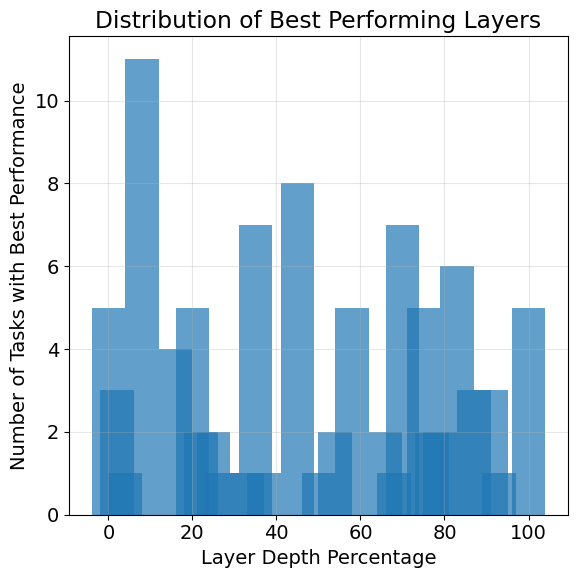

In [6]:
# plot histogram of best performing layers

specs_list = [
    TextModelSpecifications(
        model_family='Pythia',
        model_size='410m',
        revision='main',
        ignore_checks=True
    ),
    TextModelSpecifications(
        model_family='mamba',
        model_size='370m',
        revision='main',
        ignore_checks=True
    ),
    TextModelSpecifications(
        model_family='bert',
        model_size='base',
        revision='main',
        ignore_checks=True
    ),
]

model_to_label = {
    'mamba': 'Mamba-370m', 
    'bert': 'BERT-base',
    'Pythia': 'Pythia-410m'
}

plt.figure(figsize=(6, 6))

best_layer_counts = {}

for specs in specs_list:
    for layer in all_results[specs.model_family][specs.model_size]['main'].keys():
        if not layer.startswith('layer_') or '_last' in layer:
            continue
            
        layer_num = int(layer.split('_')[1])
        layer_results = all_results[specs.model_family][specs.model_size]['main'][layer]
        
        # Get main scores for each task
        for task_name, task_results in layer_results.items():
            if 'main_score' not in task_results:
                continue
                
            score = task_results['main_score']
            # if score > 0.6:  # Skip scores above 0.6
            #     continue
                
            # Check if this is the best layer for this task
            is_best = True
            for other_layer in all_results[specs.model_family][specs.model_size]['main'].keys():
                if not other_layer.startswith('layer_') or '_last' in other_layer:
                    continue
                    
                other_results = all_results[specs.model_family][specs.model_size]['main'][other_layer]
                if task_name in other_results and 'main_score' in other_results[task_name]:
                    other_score = other_results[task_name]['main_score']
                    if other_score > score:
                        is_best = False
                        break
        
            if is_best:
                depth_percentage = int((layer_num / max([int(l.split('_')[1]) for l in all_results[specs.model_family][specs.model_size]['main'].keys() if l.startswith('layer_')])) * 100)
                best_layer_counts[depth_percentage] = best_layer_counts.get(depth_percentage, 0) + 1

# Create histogram
percentages = sorted(best_layer_counts.keys())
counts = [best_layer_counts[p] for p in percentages]

plt.bar(percentages, counts, width=8, alpha=0.7)
plt.xlabel('Layer Depth Percentage')
plt.ylabel('Number of Tasks with Best Performance')
plt.title('Distribution of Best Performing Layers')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/best_layer_histogram.pdf')
plt.show()


# Metric Across Layers

In [23]:
all_results = load_all_results(should_normalize_scores_across_models=False, base_path='results')

In [21]:
all_results['Pythia']['410m']['main']['layer_0']['wikitext']['infonce']

{'raw': 5.52811244306331, 'mi-lower-bound': 0.10213881580471851}

Pythia 410m
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
bert_mean_pooling base
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
Pythia 410m
[0.8813754729320821]
[0.8675607108170443]
[0.8867594909617131]
[0.891111790682131]
[0.9024132014088678]
[0.8824046208879822]
[0.6928261583717039]
[0.6056146606856262]
[0.5706831200112481]
[0.5538453122043534]
[0.5549090036668682]
[0.5522831955895904]
[0.5374100481933645]
[0.5380117365311041]
[0.5422328070997386]
[0.5458146196372926]
[0.5574628649626246]
[0.5669622419166979]
[0.5782198539439657]
[0.5901131415986685]
[0.5924705834431193]
[0.5963127650988858]
[0.6164747522131295]
[0.7118154220295411]
[0.8600164043635206]
bert_mean_pooling base
[0.8973307657735831]
[0.9061716136150184]
[0.9094922702291612]
[0.9218352113314221]
[0.9262633070475]
[0.9225085704133685]
[0.9240316661208839]
[0.9230491648881738]
[0.9147670914598512]
[0.9066191414537099]
[0.8838763191521949]
[0.8735877808627422]
[0.8805365571431332]
Pythia 410m
[0.1856411

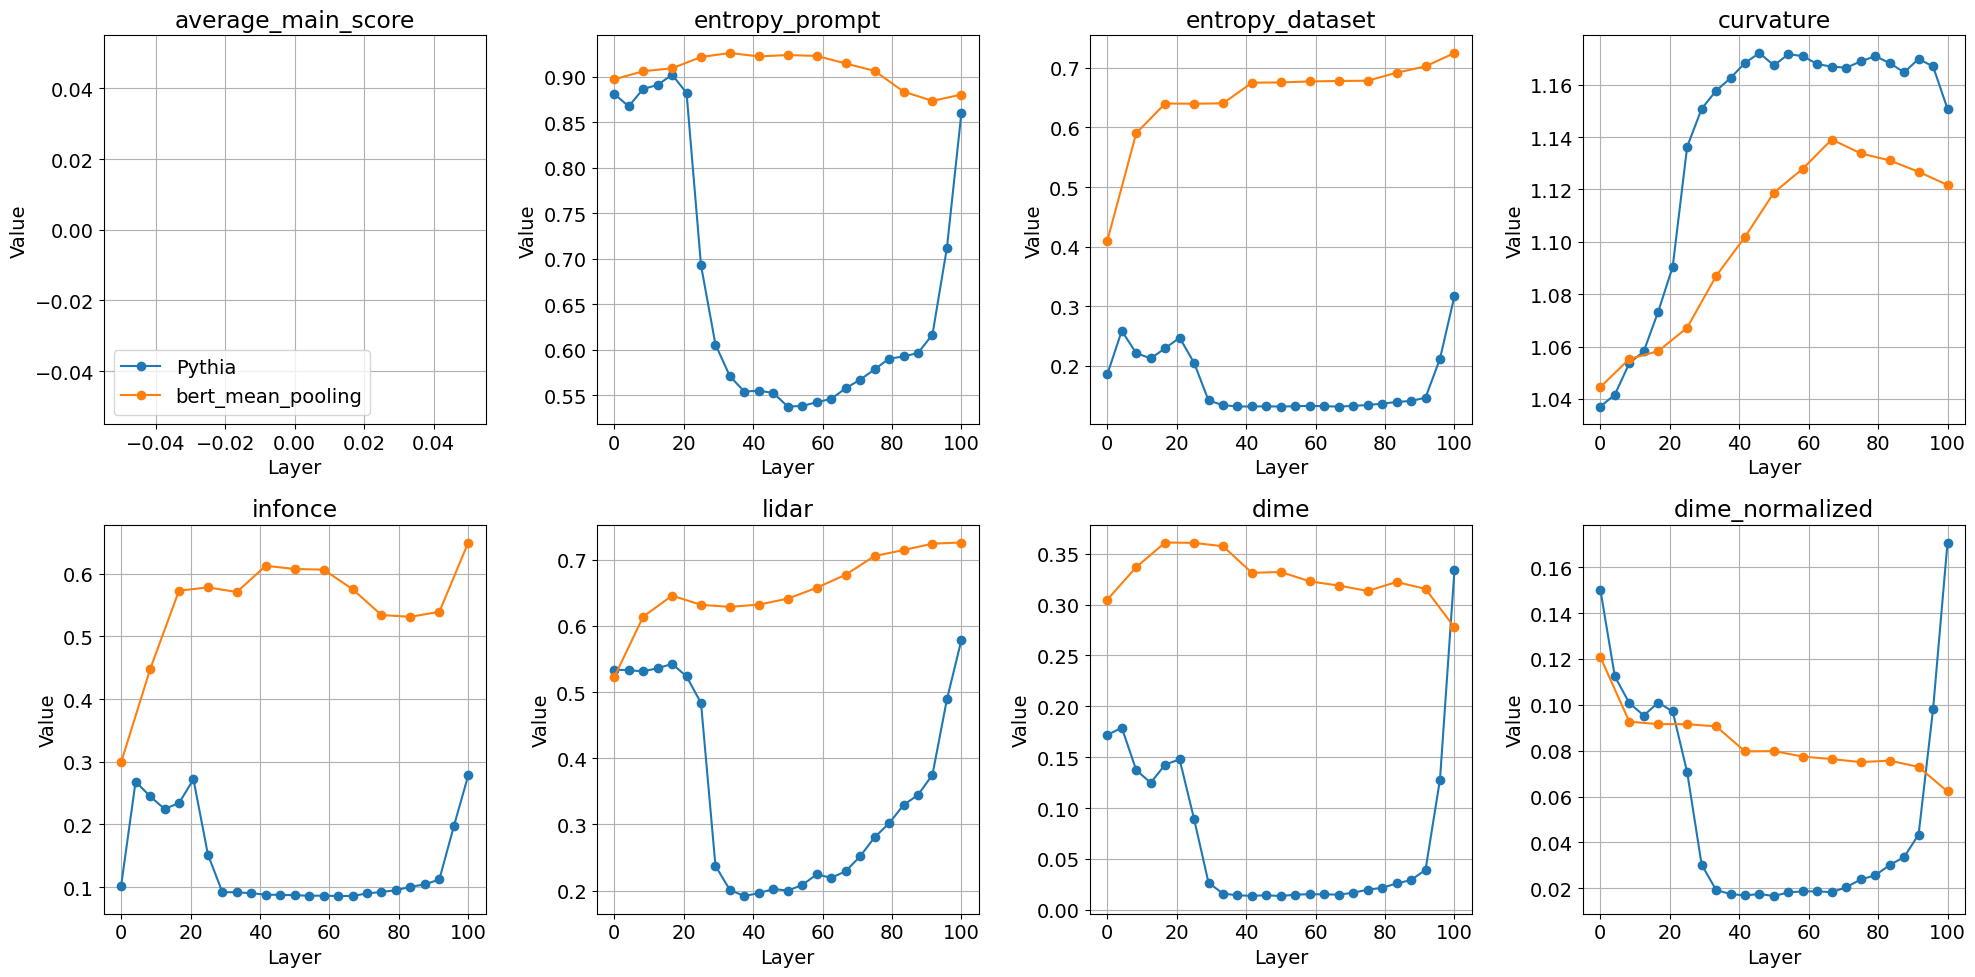

In [28]:
# plot metrics across layers

specs_list = [
    TextModelSpecifications(
        model_family='Pythia',
        model_size='410m',
        revision='main',
        ignore_checks=True
    ),
    TextModelSpecifications(
        model_family='bert_mean_pooling',
        model_size='base',
        revision='main',
        ignore_checks=True
    ),
    TextModelSpecifications(
        model_family='mamba',
        model_size='base',
        revision='main',
        ignore_checks=True
    )
]

metrics = ['average_main_score', 'entropy_prompt', 'entropy_dataset', 'curvature', 'infonce', 'lidar', 'dime', 'dime_normalized']
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for metric_idx, metric in enumerate(metrics):
    ax = axes[metric_idx]
    
    for specs in specs_list:    
        print(specs.model_family, specs.model_size)
        model_metric_values = []
        layer_nums = []
        
        for layer in all_results[specs.model_family][specs.model_size]['main'].keys():
            if not layer.startswith('layer_') or '_last' in layer:
                continue
                
            layer_num = int(layer.split('_')[1])
            layer_nums.append(layer_num)
            
            layer_results = all_results[specs.model_family][specs.model_size]['main'][layer]
            metric_values = []

            for task_name, task_results in layer_results.items():
                if task_name != 'wikitext' and task_name != 'average_main_score':
                    continue
                if metric != 'dime_normalized' and isinstance(task_results, dict) and metric not in task_results:
                    continue
                if task_name == 'average_main_score' and metric != 'average_main_score':
                    continue
                if metric == 'average_main_score':
                    # TEMP: for missing mamba tasks
                    if specs.model_family == 'mamba' and task_results > 0.6:
                        continue
                    metric_values.append(task_results)
                elif metric == 'entropy_prompt':
                    metric_values.append(task_results['entropy_prompt']['maxEntropy'])
                elif metric == 'entropy_dataset':
                    metric_values.append(task_results['entropy_dataset']['maxEntropy'])
                elif metric == 'infonce':
                    metric_values.append(task_results['infonce']['mi-lower-bound'])
                elif metric == 'lidar':
                    metric_values.append(task_results['lidar']['maxEntropy'])
                elif metric == 'dime':
                    metric_values.append(task_results['dime']['raw'])
                elif metric == 'dime_normalized':
                    if 'entropy_dataset' not in task_results:
                        continue
                    metric_values.append(task_results['dime']['raw'] / task_results['entropy_dataset']['raw'])
                elif metric == 'average_main_score':
                    metric_values.append(task_results['main_score'])
                elif metric == 'curvature':
                    metric_values.append(task_results['curvature']['raw'])

            print(metric_values)
            model_metric_values.append(np.mean(metric_values))
        
        depth_percentages = np.linspace(0, 100, len(model_metric_values))
        ax.plot(depth_percentages, model_metric_values, marker='o', label=specs.model_family)
        
    ax.set_xlabel('Layer')
    ax.set_ylabel('Value')
    ax.set_title(f'{metric}')
    ax.grid(True)

    if metric == 'average_main_score':
        ax.legend(loc='lower left')

# hide unused axes
for ax in axes:
    if ax.get_title() not in metrics:
        ax.set_visible(False)

plt.tight_layout()
plt.show()

# Image Models

In [22]:
import os 

IMAGE_MODEL_NAMES = ['clip', 'beit', 'mae', 'dinov2', 'vit', 'aim']
MODEL_TO_SIZE = {
    'clip': 'base',
    'beit': 'base',
    'mae': 'base',
    'dinov2': 'base',
    'vit': 'base',
    'aim': '3B'
}
model_to_results = {}
for model_name in IMAGE_MODEL_NAMES:
    model_to_results[model_name] = {}

    path = f'results/{model_name}/{MODEL_TO_SIZE[model_name]}/main/metrics/imagenet/val'
    for result_pkl in os.listdir(path):
        with open(os.path.join(path, result_pkl), 'rb') as f:
            metric_name = result_pkl.split('.')[0]
            model_to_results[model_name][metric_name] = pickle.load(f)

    path = f'results/{model_name}/{MODEL_TO_SIZE[model_name]}/imagenet/'
    if model_name != 'beit' and model_name != 'aim':
        result = []
        # Get all layer files and sort them numerically by layer number
        layer_files = sorted(os.listdir(path), key=lambda x: int(x.split('_')[1].split('.')[0]))
        for layer_results in layer_files:
            metric = 'linear_probe'
            with open(os.path.join(path, layer_results), 'rb') as f:
                result.append(pickle.load(f)['val_acc5'])
    
        model_to_results[model_name][metric] = result

print(model_to_results)

{'clip': {'entropy_dataset': {'maxEntropy': [0.42627614102714106, 0.5814188392455197, 0.6399572845646999, 0.6818736207342486, 0.6952247363326521, 0.7330805840268958, 0.7535143202071937, 0.7784986594327036, 0.6903851344293316, 0.7712921026578791, 0.8220068849756539, 0.8323143425273405, 0.8321225853448938], 'raw': [2.832089049241929, 3.862824514838021, 4.251741636844017, 4.530224960738431, 4.618926965477172, 4.87043325772779, 5.006190704372301, 5.172181400808222, 4.586773668039369, 5.124302552896298, 5.4612409029779485, 5.5297214836347, 5.528447489234703], 'logN': [0.4099868821147989, 0.5592011237849195, 0.6155026437865521, 0.6558172340763587, 0.6686581644736226, 0.7050674294364191, 0.724720332754748, 0.7487499472578808, 0.6640034979228786, 0.7418187741085361, 0.7905955961692185, 0.8005091756014711, 0.800324746022173], 'logNlogD': [0.061709791938366586, 0.08416899785297435, 0.09264330578007943, 0.09871131694675832, 0.10064408889063803, 0.10612428414443133, 0.10908237043368807, 0.11269922

0 linear_probe clip
clip
[2.2793169021606445, 2.3095200061798096, 3.05653977394104, 5.138530731201172, 6.805734157562256, 7.697728633880615, 10.34954833984375, 10.277061462402344, 3.809600353240967, 18.34125328063965, 43.44595718383789, 50.66849136352539, 54.85059356689453]
1 entropy_prompt clip
2 lidar clip
0 linear_probe beit
beit
1 entropy_prompt beit
2 lidar beit
0 linear_probe mae
mae
[2.7384018898010254, 6.324500560760498, 7.593024730682373, 9.902544975280762, 11.456990242004395, 15.051143646240234, 18.615093231201172, 25.434921264648438, 34.50990676879883, 51.97929763793945, 63.21681594848633, 68.0915756225586, 66.94184875488281]
1 entropy_prompt mae
2 lidar mae
0 linear_probe dinov2
dinov2
[1.1215367317199707, 1.0792526006698608, 1.024887204170227, 1.6470682621002197, 1.8202319145202637, 4.1418328285217285, 6.815802097320557, 9.25620174407959, 16.074016571044922, 23.733488082885742, 42.390865325927734, 68.12580108642578, 92.09688568115234]
1 entropy_prompt dinov2
2 lidar dinov2

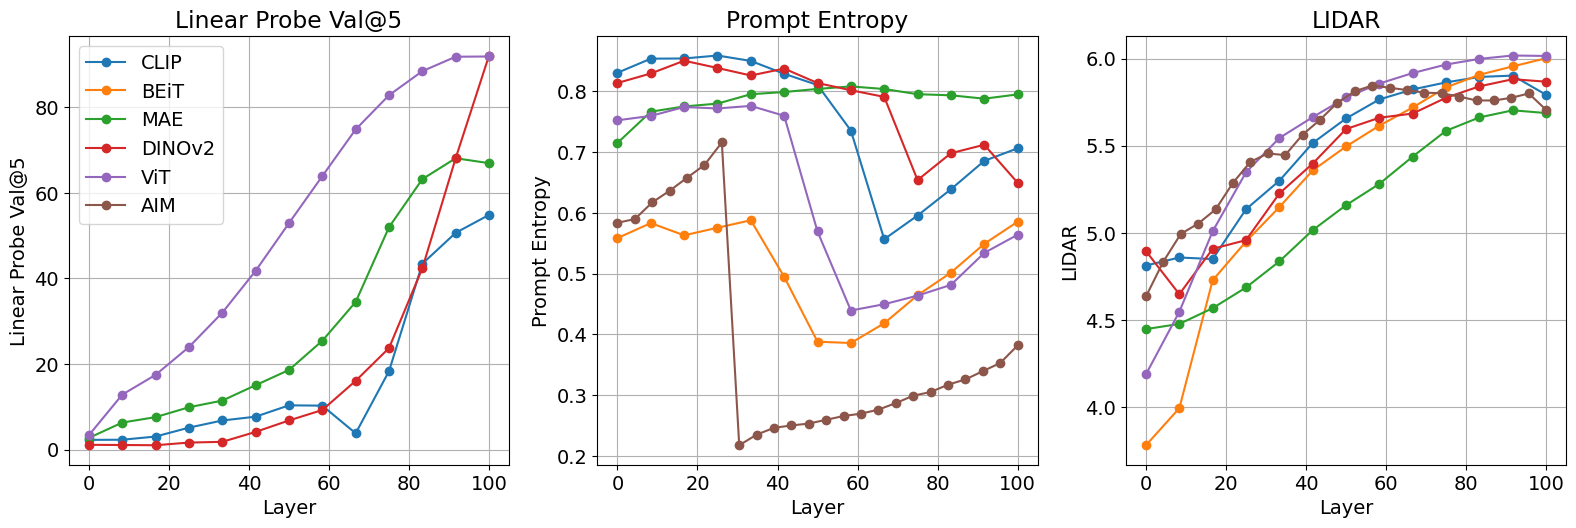

: 

In [24]:
# make 6 subplots showing each metric across layers

METRICS = ['linear_probe', 'entropy_prompt', 'lidar']
metric_to_label = {
    'linear_probe': 'Linear Probe Val@5',
    'entropy_prompt': 'Prompt Entropy', 
    'entropy_dataset': 'Dataset Entropy',
    'infonce': 'InfoNCE',
    'lidar': 'LIDAR',
    'dime': 'DIME',
    'dime_normalized': 'DIME Normalized'
}
model_to_label = {
    'clip': 'CLIP',
    'beit': 'BEiT',
    'mae': 'MAE',
    'dinov2': 'DINOv2',
    'vit': 'ViT',
    'aim': 'AIM'
}

plt.figure(figsize=(16, 10))
for model_name in IMAGE_MODEL_NAMES:
    for i, metric in enumerate(METRICS):
        plt.subplot(2, 3, i + 1)
        plt.title(metric_to_label[metric])
        plt.xlabel('Layer')
        plt.ylabel(metric_to_label[metric])
        plt.grid(True)

        print(i, metric, model_name)
        task_results = model_to_results[model_name]
        if metric == 'entropy_prompt':
            metric_values = task_results['entropy_prompt']['maxEntropy']
        elif metric == 'entropy_dataset':
            metric_values = task_results['entropy_dataset']['maxEntropy']
        elif metric == 'infonce':
            metric_values = task_results['infonce']['raw']

            # constant offset
            metric_values = [np.log(1000) - result for result in metric_values]
        elif metric == 'lidar':
            metric_values = task_results['lidar']['raw']
        elif metric == 'dime':
            metric_values = task_results['dime']['raw']
        elif metric == 'dime_normalized':
            metric_values = [task_results['dime']['raw'][idx] / task_results['entropy_dataset']['raw'][idx] for idx in range(len(task_results['dime']['raw']))]
        elif metric == 'linear_probe':
            print(model_name)
            if model_name == 'beit' or model_name == 'aim':
                metric_values = [np.nan] * len(task_results['lidar']['raw'])
            else:
                print(task_results['linear_probe'])
                metric_values = task_results['linear_probe']
        
        depth_percentages = np.linspace(0, 100, len(metric_values))
        plt.plot(depth_percentages, metric_values, label=model_to_label[model_name], marker='o')

        if i == 0:
            plt.legend()
plt.tight_layout()
plt.savefig('figures/image_models.png')
plt.show()

In [ ]:
model_to_label = {
    'clip': 'CLIP',
    'beit': 'BEiT',
    'mae': 'MAE',
    'dinov2': 'DINOv2',
    'vit': 'ViT',
    'aim': 'AIM'
}